# Real function spaces

Author: Jørgen S. Dokken

License: MIT

In this example we will show how to use the "real" function space to solve
a singular Poisson problem.

## Mathematical formulation
 The problem at hand is:
Find $u \in H^1(\Omega)$ such that


$\begin{align}
-\Delta u &= f \quad \text{in } \Omega, \\
\frac{\partial u}{\partial n} &= g \quad \text{on } \partial \Omega, \\
\int_\Omega u &= h.
\end{align}$


### Lagrange multiplier
We start by considering the equivalent optimization problem:
Find $u \in H^1(\Omega)$ such that

$$
\begin{align}
  \mathop{\mathrm{arg\,min}}_{u \in H^1(\Omega)}~J(u) =
  \mathop{\mathrm{arg\,min}}_{u \in H^1(\Omega)}~\frac{1}{2}\int_\Omega \vert \nabla u \cdot \nabla u \vert \mathrm{d}x
  - \int_\Omega f u \mathrm{d}x - \int_{\partial \Omega} g u \mathrm{d}s,
\end{align}
$$

such that

$$
\begin{align}
  \int_\Omega u = h.
\end{align}
$$

We introduce a Lagrange multiplier $\lambda$ to enforce the constraint:

$$
\begin{align}
  \mathop{\mathrm{arg\,min}}_{u \in H^1(\Omega), \lambda\in \mathbb{R}}~\mathcal{L}(u, \lambda) =
  \mathop{\mathrm{arg\,min}}_{u \in H^1(\Omega), \lambda\in \mathbb{R}} J(u) + \lambda (\int_\Omega u \mathrm{d}x-h).
\end{align}
$$

We then compute the optimality conditions for the problem above

$$
\begin{align}
\frac{\partial \mathcal{L}}{\partial u}[\delta u] &= \int_\Omega \nabla u \cdot \nabla \delta u \mathrm{d}x + \lambda\int \delta u \mathrm{d}x - \int_\Omega f \delta u ~\mathrm{d}x - \int_{\partial \Omega} g \delta u~\mathrm{d}s = 0, \\
\frac{\partial \mathcal{L}}{\partial \lambda}[\delta \lambda] &=\delta \lambda (\int_\Omega u \mathrm{d}x -h)= 0.
\end{align}
$$

We write the weak formulation:

$$
\begin{align}
\int_\Omega \nabla u \cdot \nabla \delta u~\mathrm{d}x + \int_\Omega \lambda \delta u~\mathrm{d}x &= \int_\Omega f \delta u~\mathrm{d}x + \int_{\partial \Omega} g v \mathrm{d}s\\
\int_\Omega u \delta \lambda  \mathrm{d}x &= h \delta \lambda .
\end{align}
$$

where we have moved $\delta\lambda$ into the integral as it is a spatial constant.

## Implementation
We start by import the necessary modules
```{admonition} Clickable functions/classes
Note that for the modules imported in this example, you can click on the function/class
name to be redirected to the corresponding documentation page.
```

In [1]:
from packaging.version import Version
from mpi4py import MPI
from petsc4py import PETSc
import dolfinx.fem.petsc

In [6]:
import numpy as np
from scifem import create_real_functionspace, assemble_scalar
from dolfinx.fem.petsc import apply_lifting, set_bc
import ufl
import pyvista
from dolfinx.io import gmshio

In [7]:
import gmsh

gmsh.initialize()

We start by creating the domain using {py:mod}`dolfinx` and derive the source terms
$f$, $g$ and $h$ from our manufactured solution using {py:mod}`ufl`.
For this example we will use the following exact solution

$$
\begin{align}
  u_{exact}(x, y) = 0.3y^2 + \sin(2\pi x).
\end{align}
$$

The mesh generation code below is pulled from membrane_code.ipynb of jsdokken. 

In [ ]:
unitdisk = gmsh.model.occ.addDisk(0, 0, 0, 1, 1)
gmsh.model.occ.synchronize()

gdim = 2
gmsh.model.addPhysicalGroup(gdim, [unitdisk], 1)

gmsh.option.setNumber("Mesh.CharacteristicLengthMin", 0.05)
gmsh.option.setNumber("Mesh.CharacteristicLengthMax", 0.05)
gmsh.model.mesh.generate(gdim)

gmsh_model_rank = 0
mesh_comm = MPI.COMM_WORLD

mesh, cell_markers, facet_markers = gmshio.model_to_mesh(
    gmsh.model, mesh_comm, gmsh_model_rank, gdim=gdim
)

V = dolfinx.fem.functionspace(mesh, ("Lagrange", 1))

Info    : Meshing 1D...
Info    : Meshing curve 1 (Ellipse)
Info    : Done meshing 1D (Wall 0.0126789s, CPU 0.001605s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 1.12032s, CPU 0.358525s)
Info    : 1552 nodes 3103 elements


In [9]:
def u_exact(x):
    return 0.3 * x[1] ** 2 + ufl.sin(2 * ufl.pi * x[0])

In [10]:
x = ufl.SpatialCoordinate(mesh)
n = ufl.FacetNormal(mesh)
g = ufl.dot(ufl.grad(u_exact(x)), n)
f = -ufl.div(ufl.grad(u_exact(x)))
h = assemble_scalar(u_exact(x) * ufl.dx)

### Creating the real function space and mixed space
We then create the Lagrange multiplier space using {py:func}`scifem.create_real_functionspace`.
This creates a {py:class}`dolfinx.fem.FunctionSpace` with a single degree of freedom (constant) over the whole domain.

In [11]:
R = create_real_functionspace(mesh)

Next, we can create a mixed-function space for our problem

```{admonition} Note on DOLFINx versions
The API for creating blocked problems in DOLFINx has vastly improved over the last few versions.
It is recommended to use DOLFINx v0.9.0 or later, where one can use {py:class}`ufl.MixedFunctionSpace`
to create a mixed-space of `M` number of spaces. One can then use {py:func}`ufl.TrialFunctions`
and {py:func}`ufl.TestFunctions` as one would do with a {py:func}`basix.ufl.mixed_element`.
```

In [12]:
if dolfinx.__version__ == "0.8.0":
    u = ufl.TrialFunction(V)
    lmbda = ufl.TrialFunction(R)
    du = ufl.TestFunction(V)
    dl = ufl.TestFunction(R)
elif Version(dolfinx.__version__) >= Version("0.9.0.0"):
    W = ufl.MixedFunctionSpace(V, R)
    u, lmbda = ufl.TrialFunctions(W)
    du, dl = ufl.TestFunctions(W)
else:
    raise RuntimeError("Unsupported version of dolfinx")

### Defining and assembling the variational problem
We can now define the variational problem

In [13]:
zero = dolfinx.fem.Constant(mesh, dolfinx.default_scalar_type(0.0))

In [14]:
a00 = ufl.inner(ufl.grad(u), ufl.grad(du)) * ufl.dx
a01 = ufl.inner(lmbda, du) * ufl.dx
a10 = ufl.inner(u, dl) * ufl.dx
L0 = ufl.inner(f, du) * ufl.dx + ufl.inner(g, du) * ufl.ds
L1 = ufl.inner(zero, dl) * ufl.dx

In [15]:
a = [[a00, a01], [a10, None]]
L = [L0, L1]
a_compiled = dolfinx.fem.form(a)
L_compiled = dolfinx.fem.form(L)


Note that we have defined the variational form in a block form, and
that we have not included $h$ in the variational form. We will enforce this
once we have assembled the right hand side vector.
We can now assemble the matrix and vector usig {py:func}`dolfinx.fem.petsc.assemble_matrix`
and {py:func}`dolfinx.fem.petsc.assemble_vector`.

In [16]:
try:
    A = dolfinx.fem.petsc.assemble_matrix_block(a_compiled)
except AttributeError:
    A = dolfinx.fem.petsc.assemble_matrix(a_compiled)
A.assemble()

On the main branch of DOLFINx, the `assemble_vector` function for blocked spaces has been rewritten to reflect how
it works for standard assembly and `nest` assembly. This means that lifting is applied manually.
In this case, with no Dirichlet BC, we could skip those steps.
However, for clarity we include them here.

In [17]:
bcs = []
main_assembly = False
try:
    b = dolfinx.fem.petsc.assemble_vector_block(L_compiled, a_compiled, bcs=bcs)
except AttributeError:
    main_assembly = True
    b = dolfinx.fem.petsc.assemble_vector(L_compiled, kind="mpi")
    
    apply_lifting(b, bcs, a_compiled)
    set_bc(b, bcs)
    
    # apply_lifting_and_set_bc(b, a_compiled, bcs=bcs)

Next, we modify the second part of the block to contain `h`
We start by enforcing the multiplier constraint $h$ by modifying the right hand side vector.
On the main branch, this is greatly simplified

In [18]:
uh = dolfinx.fem.Function(V, name="u")

In [19]:
if main_assembly:
    # We start by inserting the value in the real space
    rh = dolfinx.fem.Function(R)
    rh.x.array[0] = h
    # Next we need to add this value to the existing right hand side vector.
    # Therefore we create assign 0s to the primal space
    b_real_space = b.duplicate()
    uh.x.array[:] = 0
    # Transfer the data to `b_real_space`
    dolfinx.fem.petsc.assign([uh, rh], b_real_space)
    # And accumulate the values in the right hand side vector
    b.axpy(1, b_real_space)
    # We destroy the temporary work vector after usage
    b_real_space.destroy()
else:
    from dolfinx.cpp.la.petsc import scatter_local_vectors, get_local_vectors
    if Version(dolfinx.__version__) < Version("0.9.0"):
        maps = [(V.dofmap.index_map, V.dofmap.index_map_bs), (R.dofmap.index_map, R.dofmap.index_map_bs)]
    else:
        maps = [(Wi.dofmap.index_map, Wi.dofmap.index_map_bs) for Wi in W.ufl_sub_spaces()]
    b_local = get_local_vectors(b, maps)
    b_local[1][:] = h
    scatter_local_vectors(
            b,
            b_local,
            maps,
        )
    b.ghostUpdate(addv=PETSc.InsertMode.INSERT, mode=PETSc.ScatterMode.FORWARD)


### Solving the linear system
We can now solve the linear system using {py:mod}`petsc4py`.

In [20]:
ksp = PETSc.KSP().create(mesh.comm)
ksp.setOperators(A)
ksp.setType("preonly")
pc = ksp.getPC()
pc.setType("lu")
pc.setFactorSolverType("mumps")

In [21]:
if main_assembly:
    xh = b.duplicate()
else:
    xh = dolfinx.fem.petsc.create_vector_block(L_compiled)

In [22]:
ksp.solve(b, xh)
xh.ghostUpdate(addv=PETSc.InsertMode.INSERT, mode=PETSc.ScatterMode.FORWARD)


Finally, we extract the solution u from the blocked system and compute the error

In [23]:
uh = dolfinx.fem.Function(V, name="u")
if main_assembly:
    dolfinx.fem.petsc.assign(xh, [uh, rh])
else:
    x_local = get_local_vectors(xh, maps)
    uh.x.array[: len(x_local[0])] = x_local[0]
    uh.x.scatter_forward()

We destroy all PETSc objects

In [24]:
b.destroy()
xh.destroy()
A.destroy()
ksp.destroy()

### Post-processing
Finally, we compare our approximate solution with the exact solution
by computing the $L^2(\Omega)$ error.
We use the convenience function {py:func}`scifem.assemble_scalar` to compute the error.

In [25]:
diff = uh - u_exact(x)
error = ufl.inner(diff, diff) * ufl.dx
print(f"L2 error: {np.sqrt(assemble_scalar(error)):.2e}")

L2 error: 7.93e-03


We can now plot the solution

In [26]:
vtk_mesh = dolfinx.plot.vtk_mesh(V)

In [27]:
# pyvista.start_xvfb(1.0)
grid = pyvista.UnstructuredGrid(*vtk_mesh)
grid.point_data["u"] = uh.x.array.real

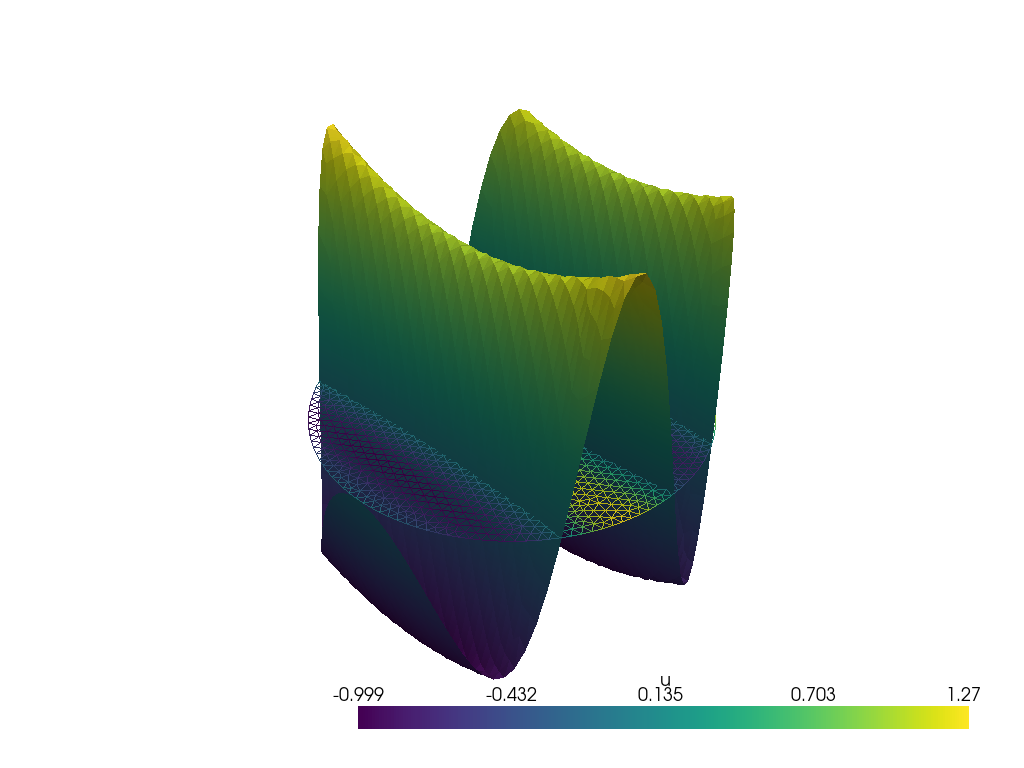

In [28]:
warped = grid.warp_by_scalar("u", factor=1)
plotter = pyvista.Plotter()
plotter.add_mesh(grid, style="wireframe")
plotter.add_mesh(warped)
if not pyvista.OFF_SCREEN:
    plotter.show()
